<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Air_Temperature_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title :  Monthly Air Temperature Forecasting Using Time Series Analysis

# Step 1: Business Understanding
# Problem Statement

The company wants to forecast future monthly air temperatures using historical temperature data.

# The goal is:

Analyze past temperature trends
Build a forecasting model
Predict future monthly temperatures



# Step 1 : Install Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Step 2 — Load Dataset

In [2]:
df = pd.read_csv("/content/surface-air-temperature-monthly-mean.csv")

In [3]:
df.head()

,month,mean_temp
0,1982-01,25.9
1,1982-02,27.1
2,1982-03,27.2
3,1982-04,27.0
4,1982-05,28.0


# Step 3 — Basic Information

In [4]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(462, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      462 non-null    object 
 1   mean_temp  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB
None
month        0
mean_temp    0
dtype: int64
0


# Step 4: Convert Month Column to Datetime
Explanation

Time series models require proper date indexing.

We convert Month into datetime format and set it as index.

In [6]:
df['month'] = pd.to_datetime(df['month'])

df.set_index('month', inplace=True)

In [7]:
df.head()

,mean_temp
month,
1982-01-01,25.9
1982-02-01,27.1
1982-03-01,27.2
1982-04-01,27.0
1982-05-01,28.0


# Step 5: Exploratory Data Analysis (EDA)
Why EDA?

EDA helps us understand:

- Trend
- Seasonality
- Outliers
- Temperature behavior over time

# Step 8 — Plot Temperature Trend

This graph helps identify:

Increasing trend
Seasonal patterns
Sudden spikes

In real companies, this step is critical because forecasting depends heavily on pattern recognition.

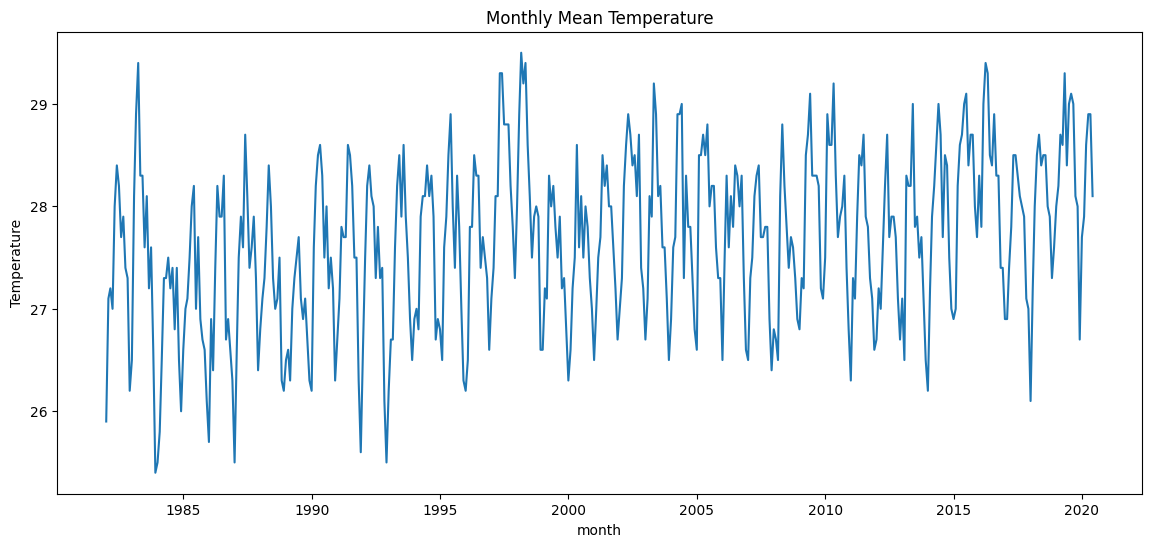

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df['mean_temp'])

plt.title('Monthly Mean Temperature')

plt.xlabel('month')
plt.ylabel('Temperature')

plt.show()

# Step 9 : Rolling Mean Visualization
Explanation

Rolling mean smooths fluctuations and helps visualize long-term trends.

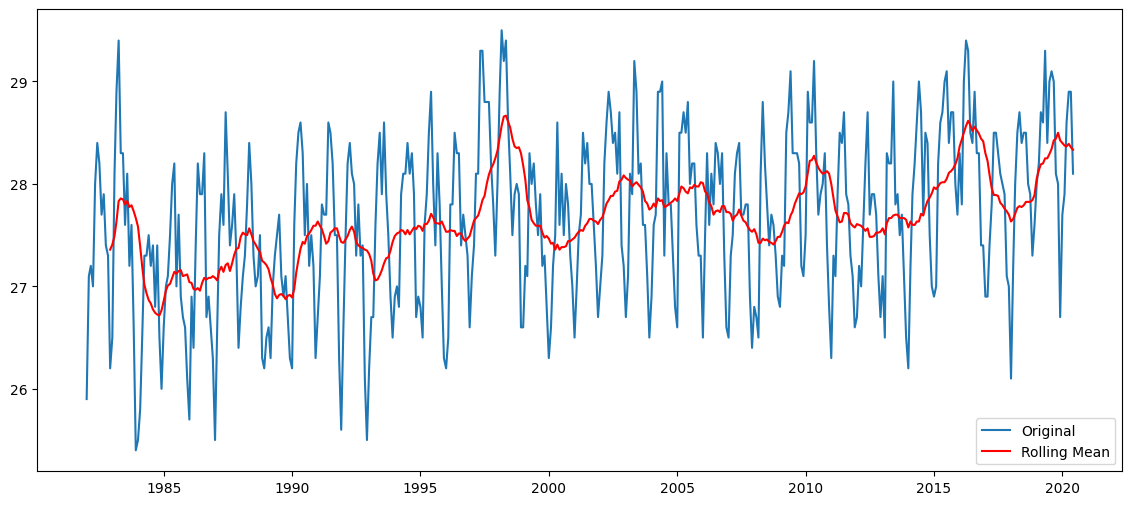

In [11]:
rolling_mean = df['mean_temp'].rolling(window=12).mean()

plt.figure(figsize=(14,6))

plt.plot(df['mean_temp'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')

plt.legend()

plt.show()

# Step 10: Check Stationarity
Why Important?

Time series models like ARIMA require stationary data.

Stationary means:

Constant mean
Constant variance
No strong trend

# Step 11 — ADF Test

In [12]:
result = adfuller(df['mean_temp'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.265046395360647
p-value: 0.0005103681123778804


# Make Data Stationary
Explanation

If p-value > 0.05:

We apply differencing.

Differencing removes trend.

# Step 12 — Differencing

In [14]:
df_diff = df['mean_temp'].diff().dropna()

# Step 13 — Plot Differenced Data

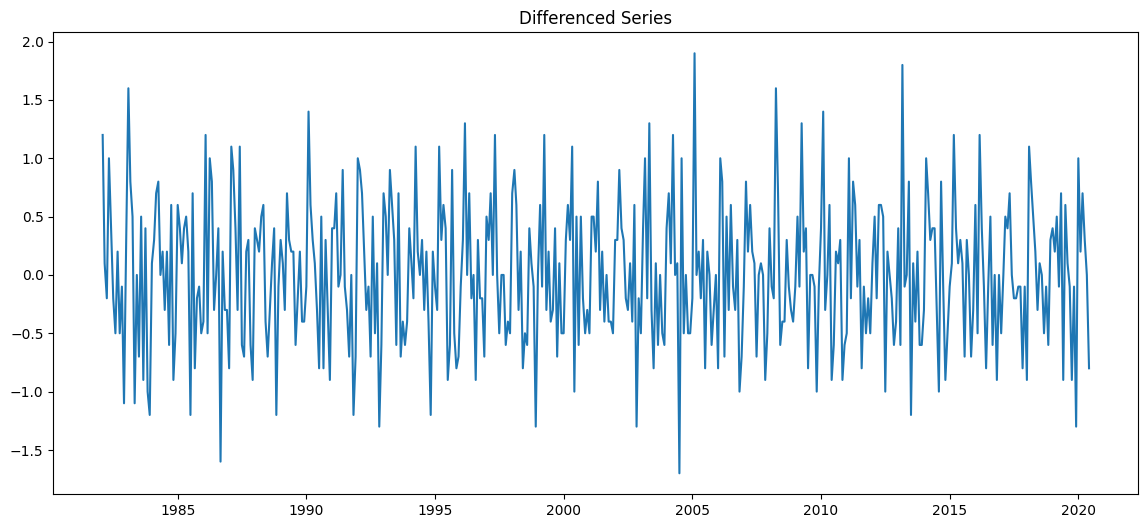

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df_diff)

plt.title('Differenced Series')

plt.show()

# Step 14 — ADF Test Again

In [16]:
result = adfuller(df_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.544123099304187
p-value: 1.675808498529023e-06


# Step 15 - Train-Test Split
Explanation

We split data into:

Training data → model learning
Testing data → evaluation

Usually:

80% Train
20% Test

# Step 16 — Split Dataset

In [18]:
train_size = int(len(df) * 0.8)

train = df['mean_temp'][:train_size]
test = df['mean_temp'][train_size:]

# Step 17 - Build ARIMA Model
Why ARIMA?

ARIMA is one of the most popular forecasting algorithms.

It works well for:

Trend forecasting
Seasonal patterns
Time-based data

In [19]:
model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

In [20]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              mean_temp   No. Observations:                  369
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -332.110
Date:                Tue, 19 May 2026   AIC                            670.220
Time:                        10:55:46   BIC                            681.945
Sample:                    01-01-1982   HQIC                           674.878
                         - 09-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9812      0.024    -40.277      0.000      -1.029      -0.933
ma.L1          0.9522      0.038     24.881      0.000       0.877       1.027
sigma2         0.3557      0.028     12.820      0.0

# Step 18 — Prediction

In [21]:
forecast = model_fit.forecast(steps=len(test))

# Step 19 — Plot Forecast

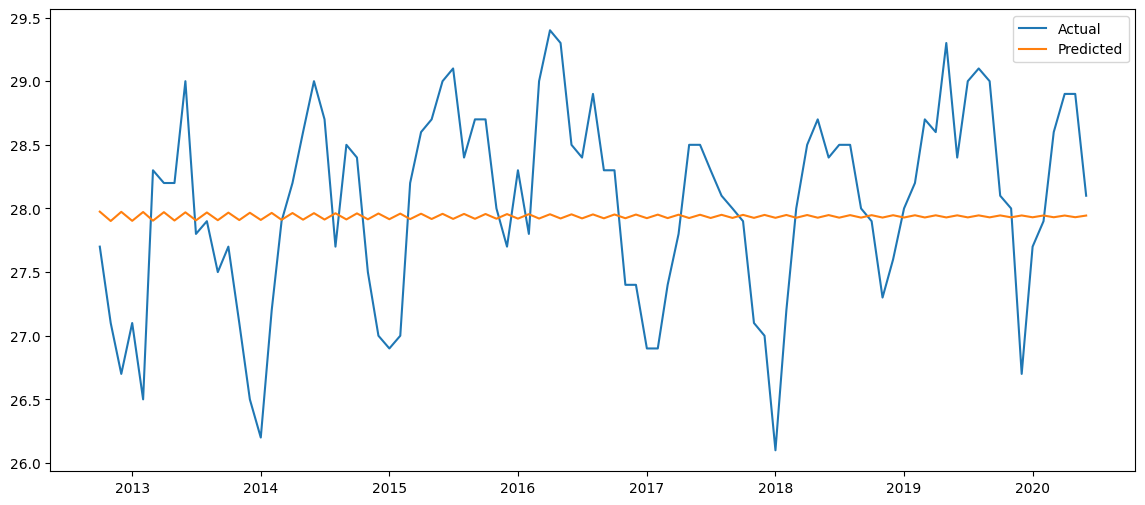

In [22]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Predicted')

plt.legend()

plt.show()

# Step 20 :Model Evaluation
Explanation

We calculate forecasting errors.

- MAE
- RMSE


In [23]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.6271050335797184
RMSE: 0.7571495611206567


# Step 21 — Future Forecast

In [24]:
future_forecast = model_fit.forecast(steps=12)

print(future_forecast)

2012-10-01    27.974843
2012-11-01    27.901411
2012-12-01    27.973459
2013-01-01    27.902769
2013-02-01    27.972126
2013-03-01    27.904076
2013-04-01    27.970843
2013-05-01    27.905335
2013-06-01    27.969609
2013-07-01    27.906546
2013-08-01    27.968420
2013-09-01    27.907713
Freq: MS, Name: predicted_mean, dtype: float64


# Step 22 — Plot Future Forecast

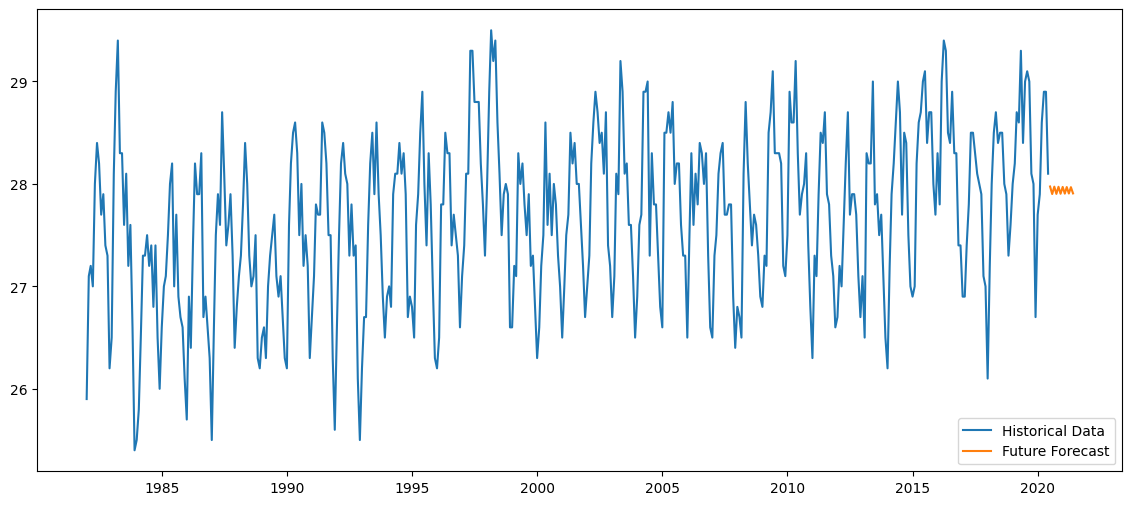

In [26]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['mean_temp'], label='Historical Data')

future_dates = pd.date_range(
    start=df.index[-1],
    periods=12,
    freq='M'
)

plt.plot(future_dates, future_forecast,
         label='Future Forecast')

plt.legend()

plt.show()

# Final Conclusion

This project successfully:

- Loaded and analyzed monthly air temperature data
- Performed time series preprocessing
- Checked stationarity
- Built ARIMA forecasting model
- Evaluated performance
- Forecasted future temperatures
- Saved trained model

This is a complete end-to-end time series forecasting project